# Titanic Survival Prediction

## Project Overview

This project analyzes passenger data from the Titanic disaster to identify factors associated with survival and evaluate the performance of multiple machine learning classification models.

# 1. Business Problem

# 2. Data Loading

# 3. Initial Exploration

# 4. Data Cleaning

# 5. Exploratory Data Analysis

# 6. Feature Engineering

# 7. Model Development

## Logistic Regression

## Decision Tree

## Naive Bayes

# 8. Model Evaluation & Comparison

# 9. Conclusions

## 1.Business Problem

The objective of this project is to analyze passenger data from the Titanic and build machine learning models capable of predicting passenger survival.

The project explores the impact of passenger demographics and travel characteristics on survival outcomes.

## 2.Data Loading

In [130]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [131]:
df = pd.read_csv(r"C:\Users\user\Desktop\git\Titanic-Survival-Prediction\data\titanic.csv")

## 3.Initial exploration

In [132]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [133]:
df.shape

(891, 12)

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [135]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [136]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 4.Data Cleaning

### Missing Values

The dataset contained missing values in the Age, Cabin, and Embarked columns.

- Cabin was dropped due to a high percentage of missing values (over 75%).
- Missing Age values were filled using the median age.
- Missing Embarked values were filled using the most frequent embarkation port.

In [137]:
df.drop('Cabin', axis=1, inplace=True)

In [138]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_13380\3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [139]:
df['Age'].fillna(df['Age'].median(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_13380\1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [140]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 5.Exploratory Data Analysis

In [141]:
#How many survived?
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [142]:
#Did gender matter?
pd.crosstab(df['Sex'], df['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [143]:
#Did passenger class matter?
pd.crosstab(df['Pclass'], df['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


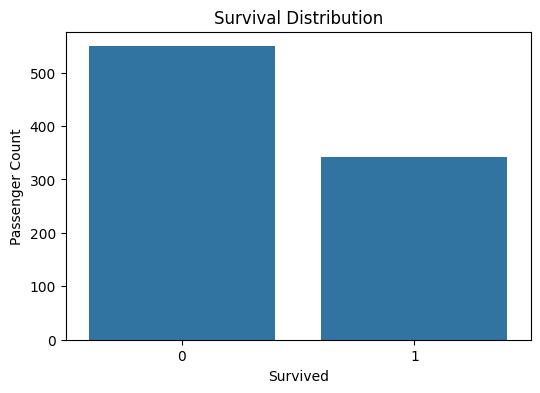

In [144]:
#Survival distribution
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Survived')

plt.title('Survival Distribution')
plt.xlabel('Survived')
plt.ylabel('Passenger Count')

plt.savefig('../images/survival_distribution.png', bbox_inches='tight')

plt.show()

### Insight

The majority of passengers did not survive the Titanic disaster. This indicates that survival was relatively uncommon, with fatalities significantly outnumbering survivors.

The distribution also highlights a class imbalance in the target variable, which is an important consideration when building and evaluating machine learning models.

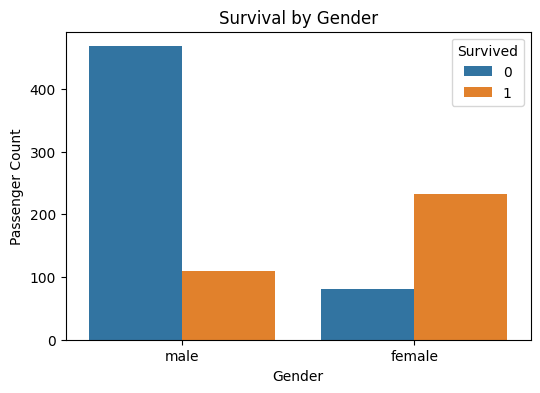

In [145]:
#Survival by gender
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Sex', hue='Survived')

plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')

plt.savefig('../images/survival_by_gender.png', bbox_inches='tight')

plt.show()

### Insight

Female passengers experienced substantially higher survival rates than male passengers.

This suggests that gender was a strong factor influencing survival outcomes and is likely to be an important predictive feature in the machine learning models.

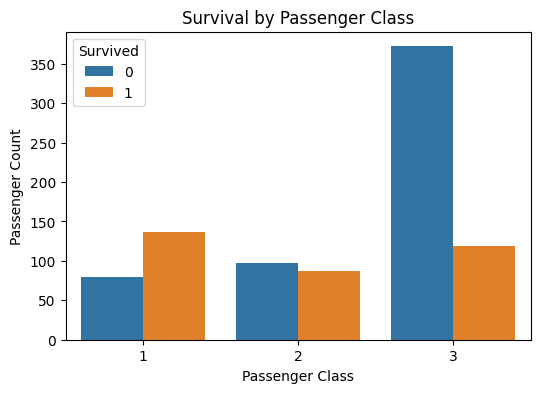

In [146]:
#Survival by Passenger Class
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Pclass', hue='Survived')

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Passenger Count')

plt.savefig('../images/survival_by_class.png', bbox_inches='tight')

plt.show()

### Insight

Passenger class appears to have had a significant impact on survival.

First-class passengers had the highest survival rates, while third-class passengers experienced the lowest survival rates. This may reflect differences in access to lifeboats, cabin location, or overall socioeconomic status.

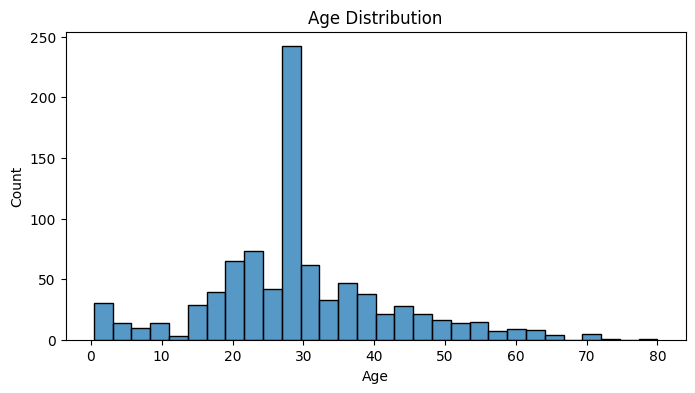

In [147]:
#Age Distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Age'], bins=30)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.savefig('../images/age_distribution.png', bbox_inches='tight')

plt.show()

### Insight

The age distribution shows that most passengers were under 30 years old, with fewer passengers in older age groups.

The distribution is slightly right-skewed, indicating that younger individuals made up the majority of the passenger population.

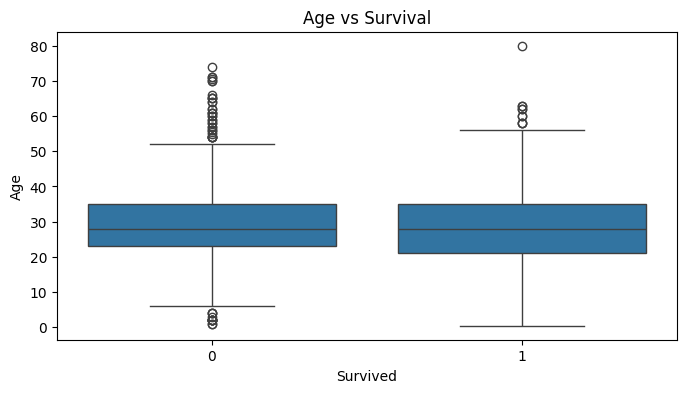

In [148]:
#Age vs Survival
plt.figure(figsize=(8,4))

sns.boxplot(data=df, x='Survived', y='Age')

plt.title('Age vs Survival')
plt.xlabel('Survived')
plt.ylabel('Age')

plt.savefig('../images/age_vs_survival.png', bbox_inches='tight')

plt.show()

### Insight

The age distributions of survivors and non-survivors show considerable overlap.

While age may have influenced survival outcomes, its relationship appears less pronounced than the effects observed for gender and passenger class.

## Summary of Exploratory Data Analysis

Key findings from the exploratory analysis include:

- Survival was less common than non-survival.
- Female passengers experienced significantly higher survival rates than male passengers.
- First-class passengers had the highest survival rates, while third-class passengers had the lowest.
- The passenger population was predominantly under 30 years old.
- Gender and passenger class appear to be strong candidate predictors for the machine learning models.

# 6. Feature Engineering

In [149]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [150]:
df_model = df.drop(['PassengerId', 'Name', 'Ticket'],axis=1)

In [151]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [152]:
df_model = pd.get_dummies(df_model,columns=['Sex', 'Embarked'],drop_first=True)

In [153]:
df_model.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [154]:
X = df_model.drop('Survived', axis=1)
y = df_model['Survived']

In [155]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# 7. Model Development

## Logistic Regression

## Decision Tree

## Naive Bayes

## Logistic Regression Model

In [156]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [157]:
y_pred = model.predict(X_test)

In [158]:
log_accuracy = accuracy_score(y_test, y_pred)
print(log_accuracy)

0.8044692737430168


In [159]:
confusion_matrix(y_test, y_pred)

array([[98, 12],
       [23, 46]])

In [160]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



## Logistic Regression Results

The Logistic Regression model was trained using demographic and travel-related passenger information.

Performance was evaluated using accuracy, a confusion matrix, and classification metrics including precision, recall, and F1-score.

### Model Accuracy

The Logistic Regression model achieved an accuracy of approximately 80%.

This indicates that the model correctly predicted passenger survival outcomes for roughly 8 out of every 10 passengers in the test dataset.

### Confusion Matrix Interpretation

The model correctly identified 98 passengers who did not survive and 46 passengers who survived.

However, it incorrectly predicted survival for 12 passengers who did not survive and failed to identify 23 passengers who actually survived.

Overall, the model performed better at identifying non-survivors than survivors.

### Classification Metrics

The model achieved strong performance in identifying passengers who did not survive, with a recall score of 89%.

Performance for predicting survivors was lower, with a recall score of 67%, indicating that some surviving passengers were incorrectly classified as non-survivors.

This suggests that the model is more effective at recognizing patterns associated with non-survival than survival.

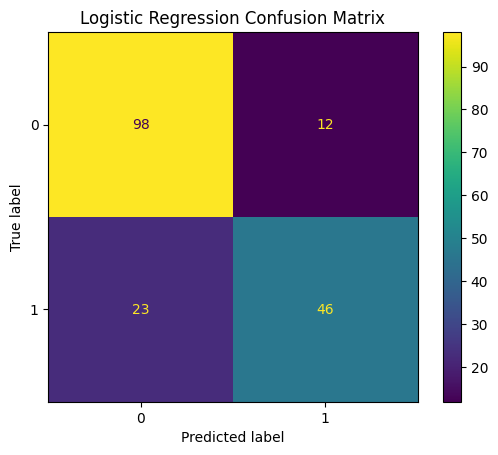

In [161]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

plt.title('Logistic Regression Confusion Matrix')

plt.savefig('../images/logistic_confusion_matrix.png',bbox_inches='tight')

plt.show()

In [162]:
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

coef_df.sort_values(by='Abs_Coefficient',ascending=False)

,Feature,Coefficient,Abs_Coefficient
5,Sex_male,-2.559300,2.559300
0,Pclass,-1.092223,1.092223
7,Embarked_S,-0.381482,0.381482
6,Embarked_Q,0.278980,0.278980
2,SibSp,-0.244502,0.244502
3,Parch,-0.071126,0.071126
1,Age,-0.038566,0.038566
4,Fare,0.002239,0.002239


### Feature Importance

The strongest predictor in the Logistic Regression model was gender.

The negative coefficient associated with male passengers indicates that males were significantly less likely to survive compared to females.

This finding aligns with the exploratory analysis, where female passengers exhibited substantially higher survival rates.

Passenger class was another important predictor of survival.

The negative coefficient suggests that passengers traveling in lower classes were less likely to survive, supporting the patterns observed during exploratory analysis.

## Key Model Findings

The Logistic Regression model identified gender and passenger class as the strongest predictors of survival.

Key observations include:

- Male passengers were significantly less likely to survive.
- Lower passenger classes were associated with reduced survival probabilities.
- Ticket fare showed a modest positive relationship with survival.
- Age demonstrated a comparatively weak influence on survival outcomes.

These findings are consistent with the patterns identified during exploratory data analysis, increasing confidence in the model's conclusions.

## Decision Tree Model

A Decision Tree classifier was trained to predict passenger survival.

Unlike Logistic Regression, Decision Trees make predictions by learning a series of decision rules from the data.

The model was evaluated using accuracy, a confusion matrix, and classification metrics to compare its performance with Logistic Regression.

In [163]:
from sklearn.tree import DecisionTreeClassifier

In [164]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [165]:
dt_pred = dt_model.predict(X_test)

In [166]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test,dt_pred)

print(dt_accuracy)

0.8212290502793296


In [167]:
confusion_matrix(y_test,dt_pred)

array([[97, 13],
       [19, 50]])

In [168]:
feature_importance = pd.DataFrame({'Feature': X.columns,'Importance': dt_model.feature_importances_})

feature_importance.sort_values(by='Importance',ascending=False)

,Feature,Importance
5,Sex_male,0.316638
1,Age,0.266991
4,Fare,0.227918
0,Pclass,0.110281
7,Embarked_S,0.032651
3,Parch,0.021010
2,SibSp,0.019053
6,Embarked_Q,0.005458


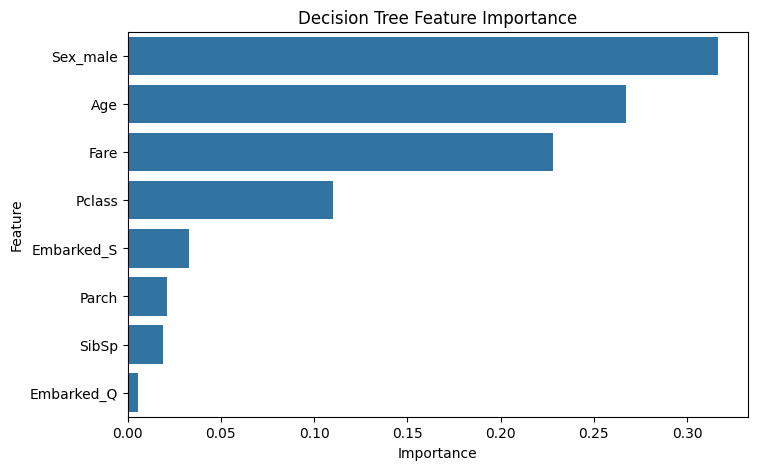

In [169]:
feature_importance = feature_importance.sort_values(by='Importance',ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(data=feature_importance,x='Importance',y='Feature')

plt.title('Decision Tree Feature Importance')

plt.savefig('../images/dt_feature_importance.png',bbox_inches='tight')

plt.show()

## Decision Tree Results

A Decision Tree classifier was trained using the same feature set as the Logistic Regression model.

Unlike Logistic Regression, which models linear relationships, Decision Trees learn decision rules by repeatedly splitting the data based on feature values.

Feature importance analysis was used to identify which variables contributed most strongly to survival predictions.

The Decision Tree model achieved an accuracy of 82.1%, slightly outperforming the Logistic Regression model.

Feature importance analysis revealed that gender was the most influential predictor of survival, followed by age, fare, and passenger class.

These findings are broadly consistent with the patterns identified during exploratory data analysis.

## Naive Bayes Model

Naive Bayes is a probabilistic classification algorithm based on Bayes' Theorem.

The model assumes that all predictor variables are independent of one another given the target variable. While this assumption is rarely true in real-world data, Naive Bayes often performs surprisingly well and serves as a useful benchmark model.

For this project, a Gaussian Naive Bayes classifier was used to predict passenger survival based on demographic and travel-related characteristics.

In [170]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [171]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Accuracy:")
print(nb_accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

Accuracy:
0.7821229050279329

Confusion Matrix:
[[92 18]
 [21 48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       110
           1       0.73      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



### Naive Bayes Results

The Gaussian Naive Bayes model achieved an accuracy of 78.21% on the test dataset.

The model correctly classified 140 out of 179 passengers and demonstrated competitive performance despite assuming independence between predictor variables.

Compared with Logistic Regression and Decision Tree, Naive Bayes produced slightly lower predictive accuracy but still captured important survival patterns within the dataset.

These results show that even relatively simple probabilistic models can perform effectively when strong predictive features are present.

## 8.Model Comparison

Three classification algorithms were evaluated on the Titanic dataset.

The Decision Tree model achieved the highest accuracy, followed by Logistic Regression and then  Naive Bayes.

While Decision Tree produced the strongest predictive performance, Logistic Regression provided greater interpretability through model coefficients. Naive Bayes offered lightweight probabilities.


In [ ]:
comparison_df = pd.DataFrame({"Model": ["Logistic Regression","Decision Tree","Naive Bayes"],
    "Accuracy": [log_accuracy,dt_accuracy,nb_accuracy]})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.804469
1,Decision Tree,0.821229
2,Naive Bayes,0.782123


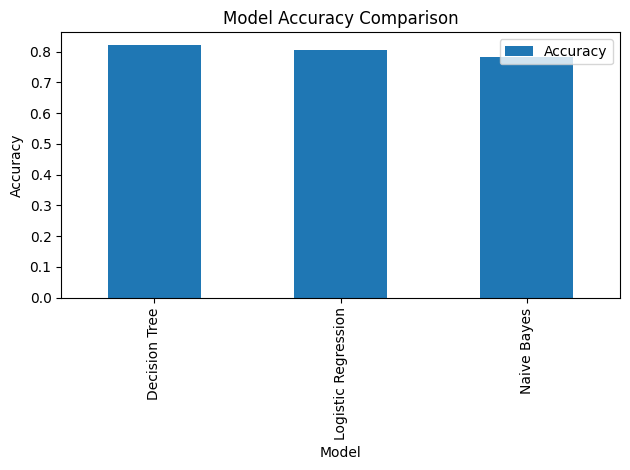

In [173]:
import matplotlib.pyplot as plt

comparison_df.sort_values(by="Accuracy",ascending=False).plot(x="Model",y="Accuracy",kind="bar")

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.tight_layout()

plt.savefig("../images/model_comparison.png",bbox_inches="tight")

plt.show()

### Model Comparison Summary

Decision Tree achieved the highest accuracy (82.12%), followed by Logistic Regression (80.45%) and Naive Bayes (78.21%).

While Decision Tree provided the strongest predictive performance, Logistic Regression offered greater interpretability through model coefficients. Naive Bayes served as a useful probabilistic benchmark but was less efficient than the other models.

Overall, the results suggest that passenger gender and class contained strong predictive signals that could be leveraged by multiple modeling approaches.

# 9.Conclusions

This project analyzed passenger data from the Titanic disaster to identify factors associated with survival and evaluate the effectiveness of different machine learning classification models.

The analysis revealed several important patterns:

* Gender was the strongest predictor of survival.
* Passenger class significantly influenced survival outcomes.
* First-class passengers experienced considerably higher survival rates than third-class passengers.
* Age contributed to prediction performance but was less influential than gender and passenger class.

Three machine learning models were developed and evaluated:

| Model               | Accuracy |
| ------------------- | -------- |
| Decision Tree       | 82.12%   |
| Logistic Regression | 80.45%   |
| Naive Bayes         | 78.21%   |

Among the models tested, Decision Tree achieved the highest predictive accuracy. Logistic Regression provided strong performance while offering greater interpretability through model coefficients. Naive Bayes served as a useful probabilistic benchmark based on its simplifying assumptions.

This project demonstrates the complete data science workflow, including data cleaning, exploratory data analysis, feature engineering, model development, model evaluation, and communication of analytical findings.

The results highlight how demographic and socioeconomic factors influenced survival outcomes and illustrate how machine learning models can be used to uncover and quantify these relationships.
